# Assignment 2 2AMM10 2023-2024

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [ ]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [1]:
!pip show torch

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [ ]:
!pip install rdkit
!pip install torch_geometric
!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 85.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.8 MB/s eta 0:00:00


In [4]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

In [5]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [6]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [ ]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


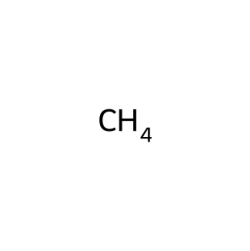

In [ ]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.045│     1.483│     0.117
  C  │  6   │    -0.048│    -0.037│    -0.062
  C  │  6   │     0.805│    -0.487│    -1.241
  O  │  8   │     0.740│    -1.894│    -1.334
  C  │  6   │     1.414│    -2.470│    -2.450
  C  │  6   │     2.917│    -2.575│    -2.170
  C  │  6   │     0.740│    -3.828│    -2.721
  C  │  6   │    -0.758│    -3.647│    -3.003
  C  │  6   │     1.416│    -4.595│    -3.866
  H  │  1   │     0.968│     1.862│     0.296
  H  │  1   │    -0.436│     1.990│    -0.771
  H  │  1   │    -0.664│     1.781│     0.968
  H  │  1   │     0.325│    -0.528│     0.845
  H  │  1   │    -1.071│    -0.400│    -0.213
  H  │  1   │     0.438│    -0.026│    -2.175
  H  │  1   │     1.843│    -0.141│    -1.102
  H  │  1   │     1.258│    -1.824│    -3.332
  H  │  1   │     3.106│    -3.282│    -1.356
  H  │  1   │     3.468│    -2.907│    -3.054
  H  │  1   │     3.328│    -1.604

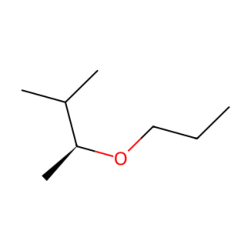

In [ ]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

In [7]:
! pip install deepchem
from deepchem.feat.smiles_tokenizer import BasicSmilesTokenizer

wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [8]:
from collections import Counter
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

In [9]:
tokenizer = BasicSmilesTokenizer()
counter = Counter()
for s in smiles_data:
  counter.update(tokenizer.tokenize(s))

vocab = {}
for k, v in counter.items():
  vocab[k] = len(vocab) + 1
vocab['<pad>'] = 0
vocab['<unk>'] = len(vocab)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SMILESDataset(Dataset):
  def __init__(self, smiles_data, fe, vocab):
    self.smiles_data = smiles_data
    self.fe = fe
    self.vocab = vocab
    tokenizer = BasicSmilesTokenizer()
    self.tokenized_smiles = [tokenizer.tokenize(s) for s in smiles_data]

  def __len__(self):
    return len(self.smiles_data)

  def __getitem__(self, idx):
    int_smiles = [vocab.get(token, vocab['<unk>']) for token in self.tokenized_smiles[idx]]
    return int_smiles, self.fe[idx]

def collate_fn(batch):
    label_list, smiles_list = [], []
    for (_smiles, _label) in batch:
      smiles_list.append(torch.tensor(_smiles, dtype=torch.int64))
      label_list.append(_label)

    smiles_batch = pad_sequence(smiles_list, batch_first=True, padding_value=0)
    label_batch = torch.tensor(label_list, dtype=torch.float32)

    return smiles_batch.to(device), label_batch.to(device)


In [40]:
class RNNRegressionModel(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
    super(RNNRegressionModel, self).__init__()
    self.num_layers = num_layers
    self.embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
    self.fc1 = nn.Linear(hidden_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, 1)
    self.drop = nn.Dropout(0.5)
    self.criterion = nn.MSELoss()
    # self.optimizer = torch.optim.Adam(self.parameters())

  def forward(self, x):
    x = self.embeddings(x)
    out, (hidden, _) = self.rnn(x)
    last_timestep = out[:, -1]
    last_timestep = self.drop(last_timestep)
    h = self.fc1(last_timestep)
    h = self.drop(h)
    h = nn.ReLU()(h)
    y_pred = self.fc2(h).squeeze(1)
    return y_pred

In [41]:
def mse(y_true, y_pred):
  return torch.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
  ss_res = torch.sum((y_true - y_pred) ** 2)
  ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
  return 1 - (ss_res / ss_tot)

In [42]:
def train(model, dataloader):
  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
  y_true_list, y_pred_list = [], []
  for x_batch, y_true in dataloader:
    optimizer.zero_grad()
    y_pred = model(x_batch)
    loss = model.criterion(y_pred, y_true)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
    optimizer.step()
    y_true_list.append(y_true.cpu())
    y_pred_list.append(y_pred.cpu())

  y_true = torch.cat(y_true_list)
  y_pred = torch.cat(y_pred_list)

  return mse(y_true, y_pred)

def evaluate(model, dataloader):
  model.eval()
  y_true_list, y_pred_list = [], []
  with torch.no_grad():
    for x_batch, y_true in dataloader:
      y_pred = model(x_batch)
      loss = model.criterion(y_pred, y_true)
      y_true_list.append(y_true.cpu())
      y_pred_list.append(y_pred.cpu())

  y_true = torch.cat(y_true_list)
  y_pred = torch.cat(y_pred_list)

  return mse(y_true, y_pred), r2_score(y_true, y_pred)

In [43]:
def split_train_val_set(data_list, label_list, idx, vocab, val_ratio=0.1):
  """
  Construct training set and validation set.
  """
  dataset_size = len(idx)
  val_size = int(np.floor(val_ratio * dataset_size))
  shuffed_idx = np.random.permutation(idx)
  x_train = [data_list[i] for i in shuffed_idx[:-val_size]]
  x_val = [data_list[i] for i in shuffed_idx[-val_size:]]
  y_train = [label_list[i] for i in shuffed_idx[:-val_size]]
  y_val = [label_list[i] for i in shuffed_idx[-val_size:]]
  train_set = SMILESDataset(x_train, y_train, vocab)
  val_set = SMILESDataset(x_val, y_val, vocab)

  return train_set, val_set


In [44]:
model = RNNRegressionModel(len(vocab), embed_dim=512, hidden_dim=128, num_layers=2).to(device)
batch_size = 128
epochs = 10

# Training loop
original_fe = fe * std + mu

for epoch in tqdm(range(epochs)):
  train_loss, val_loss = 0, 0
  train_set, val_set = split_train_val_set(smiles_data, original_fe, train_idxes, vocab)
  train_dl = DataLoader(train_set, batch_size=batch_size, collate_fn=collate_fn)
  val_dl = DataLoader(val_set, batch_size=batch_size, collate_fn=collate_fn)

  train_loss = train(model, train_dl)
  val_loss, r2 = evaluate(model, val_dl)

  # print the results
  print(
    f'EPOCH: {epoch+1:0>{len(str(epochs))}}/{epochs}',
    end=' '
  )
  print(f'LOSS: {train_loss:.4f}',end=' ')
  print(f'VAL-LOSS: {val_loss:.4f}  VAL-R squared score: {r2:.4f}',end='\n')

 10%|█         | 1/10 [00:05<00:49,  5.53s/it]

EPOCH: 01/10 LOSS: 2362.9724 VAL-LOSS: 111.2844  VAL-R squared score: -0.0257


 20%|██        | 2/10 [00:11<00:48,  6.04s/it]

EPOCH: 02/10 LOSS: 161.2312 VAL-LOSS: 21.2198  VAL-R squared score: 0.7978


 30%|███       | 3/10 [00:17<00:40,  5.75s/it]

...

EPOCH: 08/10 LOSS: 118.7877 VAL-LOSS: 6.6382  VAL-R squared score: 0.9382


 90%|█████████ | 9/10 [00:53<00:05,  5.88s/it]

EPOCH: 09/10 LOSS: 116.4368 VAL-LOSS: 9.1941  VAL-R squared score: 0.9139


100%|██████████| 10/10 [00:59<00:00,  5.92s/it]

EPOCH: 10/10 LOSS: 116.5545 VAL-LOSS: 5.3339  VAL-R squared score: 0.9495


In [45]:
# Construct test dataloader
smiles_test = [smiles_data[i] for i in test_idxes]
fe_test = [original_fe[i] for i in test_idxes]
test_set = SMILESDataset(smiles_test, fe_test, vocab)
test_dl = DataLoader(test_set, batch_size=batch_size, collate_fn=collate_fn)

# Evaluate model on test set
test_loss, r2 = evaluate(model, test_dl)
print(f'TEST-LOSS: {test_loss:.4f}  TEST-R squared score: {r2:.4f}')

TEST-LOSS: 6.0651  TEST-R squared score: 0.9435


In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.optimizer.state_dict(),
}, 'RNN_all_checkpoint.pth')

## Task 2

In [46]:
def train_on_subset(model, subset_size, batch_size=128, epochs=10):
  for epoch in tqdm(range(epochs)):
    train_loss, val_loss = 0, 0
    train_set, val_set = split_train_val_set(smiles_data, original_fe, train_idxes[:subset_size], vocab)
    train_dl = DataLoader(train_set, batch_size=batch_size, collate_fn=collate_fn)
    val_dl = DataLoader(val_set, batch_size=batch_size, collate_fn=collate_fn)

    train_loss = train(model, train_dl)
    val_loss, r2 = evaluate(model, val_dl)

    # print the results
    print(
      f'EPOCH: {epoch+1:0>{len(str(epochs))}}/{epochs}',
      end=' '
    )
    print(f'LOSS: {train_loss:.4f}',end=' ')
    print(f'VAL-LOSS: {val_loss:.4f}  VAL-R squared score: {r2:.4f}',end='\n')


In [47]:
# Train models on subsets of differnt size
subset_sizes = [100,300,1000,3000,10000]
models = []

for subset_size in subset_sizes:
  print(f"== Training on subset of size {subset_size} ==", end='\n')
  model = RNNRegressionModel(len(vocab), embed_dim=512, hidden_dim=128, num_layers=2).to(device)
  train_on_subset(model, subset_size)
  models.append(model)


== Training on subset of size 100 ==


100%|██████████| 10/10 [00:00<00:00, 97.00it/s]


EPOCH: 01/10 LOSS: 5929.7402 VAL-LOSS: 5842.5967  VAL-R squared score: -46.8136
EPOCH: 02/10 LOSS: 5836.1279 VAL-LOSS: 6678.8975  VAL-R squared score: -30.8992
EPOCH: 03/10 LOSS: 6013.6992 VAL-LOSS: 5073.6670  VAL-R squared score: -30.9789
EPOCH: 04/10 LOSS: 5991.1387 VAL-LOSS: 5263.6191  VAL-R squared score: -26.3703
EPOCH: 05/10 LOSS: 5823.6279 VAL-LOSS: 6761.7798  VAL-R squared score: -59.3331
EPOCH: 06/10 LOSS: 5820.6846 VAL-LOSS: 6782.6328  VAL-R squared score: -64.5410
EPOCH: 07/10 LOSS: 5828.7349 VAL-LOSS: 6701.2109  VAL-R squared score: -67.2445
EPOCH: 08/10 LOSS: 5962.9824 VAL-LOSS: 5485.2085  VAL-R squared score: -31.1624
EPOCH: 09/10 LOSS: 6016.9395 VAL-LOSS: 4984.9131  VAL-R squared score: -35.2918
EPOCH: 10/10 LOSS: 5900.2749 VAL-LOSS: 6031.5537  VAL-R squared score: -34.9048
== Training on subset of size 300 ==


  0%|          | 0/10 [00:00<?, ?it/s]

EPOCH: 01/10 LOSS: 5900.8110 VAL-LOSS: 5536.0791  VAL-R squared score: -47.1732
EPOCH: 02/10 LOSS: 5887.6963 VAL-LOSS: 5628.2998  VAL-R squared score: -41.0188
EPOCH: 03/10 LOSS: 5817.5742 VAL-LOSS: 6247.4077  VAL-R squared score: -44.8036


...

EPOCH: 08/10 LOSS: 913.9988 VAL-LOSS: 603.0749  VAL-R squared score: -4.1913


 90%|█████████ | 9/10 [00:04<00:00,  1.86it/s]

EPOCH: 09/10 LOSS: 488.7712 VAL-LOSS: 223.3602  VAL-R squared score: -1.1439


100%|██████████| 10/10 [00:05<00:00,  1.95it/s]

EPOCH: 10/10 LOSS: 259.6989 VAL-LOSS: 106.7946  VAL-R squared score: -0.0356


In [48]:
# Evaluate model trained on subsets of differnt size
for i in range(len(models)):
  subset_size = subset_sizes[i]
  model = models[i]
  print(f"== Evaluate model trained on subset of size {subset_size} ==", end='\n')
  test_loss, r2 = evaluate(model, test_dl)
  print(f'TEST-LOSS: {test_loss:.4f}  TEST-R squared score: {r2:.4f}')
  print()

== Evaluate model trained on subset of size 100 ==
TEST-LOSS: 5881.7632  TEST-R squared score: -53.7949

== Evaluate model trained on subset of size 300 ==
TEST-LOSS: 5853.1807  TEST-R squared score: -53.5286

== Evaluate model trained on subset of size 1000 ==
TEST-LOSS: 5546.0674  TEST-R squared score: -50.6675

== Evaluate model trained on subset of size 3000 ==
TEST-LOSS: 4465.1680  TEST-R squared score: -40.5978

== Evaluate model trained on subset of size 10000 ==
TEST-LOSS: 110.0899  TEST-R squared score: -0.0256



## Task 3

In [ ]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [ ]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [ ]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)